In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import auc, roc_curve, precision_recall_curve, average_precision_score


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for _ in range(5):
        if (here / "hpc").exists():
            return here
        here = here.parent
    return Path.cwd().resolve()


ROOT = find_repo_root()
BEFORE_CSV = ROOT / "hpc/before_finetuning_results_full.csv"
FINETUNED_CSV = ROOT / "hpc/finetuned_results.csv"

before_df_raw = pd.read_csv(BEFORE_CSV, sep=";")
finetuned_df_raw = pd.read_csv(FINETUNED_CSV, sep=";")

print("ROOT:", ROOT)
print("before:", before_df_raw.shape)
print("finetuned:", finetuned_df_raw.shape)


def _to01(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False).astype(int)
    s = series.fillna(False).astype(str).str.strip().str.lower()
    trueish = s.isin(["true", "1", "yes", "y", "t"])
    falseish = s.isin(["false", "0", "no", "n", "f", "nan", "none", ""])
    out = pd.Series(np.where(trueish, 1, np.where(falseish, 0, 0)), index=series.index)
    return out.astype(int)


def normalize_frame(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()

    for col in ["dataset", "categorie", "subcategorie"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")
        df[col] = df[col].fillna("NA").astype(str)

    for col in ["first_try_correct", "second_try_correct"]:
        if col in df.columns:
            df[col] = _to01(df[col])
        else:
            df[col] = 0

    for metric in ["max_prob", "entropy", "margin", "verbal"]:
        for try_name in ["first", "second"]:
            col = f"{try_name}_try_{metric}"
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


before_df = normalize_frame(before_df_raw)
finetuned_df = normalize_frame(finetuned_df_raw)


def single_answer_mask(df: pd.DataFrame) -> pd.Series:
    return (~df["dataset"].str.contains("maqa", case=False, na=False)) | (df["dataset"].str.contains("single", case=False, na=False))


before_single = before_df[single_answer_mask(before_df)].copy()
finetuned_single = finetuned_df[single_answer_mask(finetuned_df)].copy()

print("before single:", before_single.shape)
print("finetuned single:", finetuned_single.shape)

ROOT: /home/oskar/school/transformers/tf_project
before: (25455, 19)
finetuned: (24889, 19)
before single: (15979, 19)
finetuned single: (15418, 19)


/tmp/ipykernel_39009/1253642134.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.fillna(False).astype(str).str.strip().str.lower()
/tmp/ipykernel_39009/1253642134.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = series.fillna(False).astype(str).str.strip().str.lower()


In [36]:
METRICS = ["max_prob", "entropy", "margin", "verbal"]
METRIC_COLORS = {
    "max_prob": "tab:blue",
    "entropy": "tab:orange",
    "margin": "tab:green",
    "verbal": "tab:red",
}


def _score_col(try_name: str, metric: str) -> str:
    return f"{try_name}_try_{metric}"


def _label_col(try_name: str) -> str:
    return f"{try_name}_try_correct"


def _coerce_numeric(series: pd.Series) -> np.ndarray:
    return pd.to_numeric(series, errors="coerce").astype(float).to_numpy()


def _invert_scores(scores: np.ndarray) -> np.ndarray:
    scores = scores.astype(float)
    finite = np.isfinite(scores)
    if not finite.any():
        return scores
    max_val = float(np.nanmax(scores[finite]))
    scale = 1.0 if max_val <= 1.0 else 100.0
    return scale - scores


def compute_roc(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or np.unique(y).size < 2:
        return None
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr, float(auc(fpr, tpr))


def compute_pr(y_true: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, float] | None:
    mask = np.isfinite(scores)
    y = y_true[mask]
    s = scores[mask]
    if y.size == 0 or y.sum() == 0:
        return None
    precision, recall, _ = precision_recall_curve(y, s)
    ap = float(average_precision_score(y, s))
    return recall, precision, ap


def iter_groups(frame: pd.DataFrame):
    keys = ("dataset", "categorie", "subcategorie")
    for (dataset, categorie, subcategorie), g in frame.groupby(list(keys), dropna=False):
        yield (str(dataset), str(categorie), str(subcategorie)), g.copy()


def _pad_curve_to_unit_interval(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if x.size == 0:
        return x, y
    if x[0] > 0:
        x = np.concatenate([[0.0], x])
        y = np.concatenate([[y[0]], y])
    if x[-1] < 1:
        x = np.concatenate([x, [1.0]])
        y = np.concatenate([y, [y[-1]]])
    return x, y


def average_roc_curves(
    frame: pd.DataFrame,
    *,
    choose_by_plain_threshold: float = 0.5,
    fpr_grid: np.ndarray | None = None,
 ) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]]:
    """Return one ROC curve per (try_name, metric).
    If plain AUROC < threshold, plot the inverted-score ROC instead (when available).
    """
    if fpr_grid is None:
        fpr_grid = np.linspace(0.0, 1.0, 201)

    def _mean_roc_for(try_name: str, metric: str, *, inverted: bool) -> tuple[np.ndarray, float] | None:
        tprs: list[np.ndarray] = []
        for (_key, g) in iter_groups(frame):
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            if inverted:
                scores = _invert_scores(scores)
            roc_res = compute_roc(y_true, scores)
            if roc_res is None:
                continue
            fpr, tpr, _ = roc_res
            fpr, tpr = _pad_curve_to_unit_interval(fpr, tpr)
            tprs.append(np.interp(fpr_grid, fpr, tpr))
        if not tprs:
            return None
        mean_tpr = np.mean(np.vstack(tprs), axis=0)
        return mean_tpr, float(auc(fpr_grid, mean_tpr))

    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for try_name in ["first", "second"]:
        for metric in METRICS:
            plain = _mean_roc_for(try_name, metric, inverted=False)
            if plain is None:
                continue
            mean_tpr_plain, auc_plain = plain
            want_invert = auc_plain < choose_by_plain_threshold
            if want_invert:
                inv = _mean_roc_for(try_name, metric, inverted=True)
                if inv is not None:
                    mean_tpr_inv, auc_inv = inv
                    out[(try_name, metric)] = (fpr_grid, mean_tpr_inv, float(auc_inv), True)
                    continue
            out[(try_name, metric)] = (fpr_grid, mean_tpr_plain, float(auc_plain), False)
    return out


def average_pr_curves(
    frame: pd.DataFrame,
    *,
    orientation: dict[tuple[str, str], bool] | None = None,
    recall_grid: np.ndarray | None = None,
 ) -> dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]]:
    """Return one PR curve per (try_name, metric), matching a given ROC-based orientation."""
    if recall_grid is None:
        recall_grid = np.linspace(0.0, 1.0, 201)
    if orientation is None:
        roc_curves = average_roc_curves(frame)
        orientation = {k: inv for k, (_x, _y, _auc, inv) in roc_curves.items()}

    def _mean_pr_for(try_name: str, metric: str, *, inverted: bool) -> tuple[np.ndarray, float] | None:
        precs: list[np.ndarray] = []
        aps: list[float] = []
        for (_key, g) in iter_groups(frame):
            lbl_col = _label_col(try_name)
            sc_col = _score_col(try_name, metric)
            if lbl_col not in g.columns or sc_col not in g.columns:
                continue
            y_true = g[lbl_col].to_numpy(dtype=int)
            scores = _coerce_numeric(g[sc_col])
            if inverted:
                scores = _invert_scores(scores)
            pr_res = compute_pr(y_true, scores)
            if pr_res is None:
                continue
            recall, precision, ap = pr_res
            recall = recall[::-1]
            precision = precision[::-1]
            recall, precision = _pad_curve_to_unit_interval(recall, precision)
            precs.append(np.interp(recall_grid, recall, precision))
            aps.append(float(ap))
        if not precs:
            return None
        mean_prec = np.mean(np.vstack(precs), axis=0)
        mean_ap = float(np.mean(aps)) if aps else float("nan")
        return mean_prec, mean_ap

    out: dict[tuple[str, str], tuple[np.ndarray, np.ndarray, float, bool]] = {}
    for try_name in ["first", "second"]:
        for metric in METRICS:
            inv = bool(orientation.get((try_name, metric), False))
            mean_prec = _mean_pr_for(try_name, metric, inverted=inv)
            if mean_prec is None and inv:
                mean_prec = _mean_pr_for(try_name, metric, inverted=False)
                inv = False
            if mean_prec is None:
                continue
            prec, ap = mean_prec
            out[(try_name, metric)] = (recall_grid, prec, float(ap), inv)
    return out


def average_pr_baseline(frame: pd.DataFrame) -> float:
    rates = []
    for (_key, g) in iter_groups(frame):
        if "first_try_correct" in g.columns:
            rates.append(float(g["first_try_correct"].mean()))
    return float(np.mean(rates)) if rates else 0.0


def _second_try_gain(frame: pd.DataFrame) -> np.ndarray:
    first = frame["first_try_correct"].to_numpy(dtype=int)
    second = frame["second_try_correct"].to_numpy(dtype=int)
    return ((first == 0) & (second == 1)).astype(int)

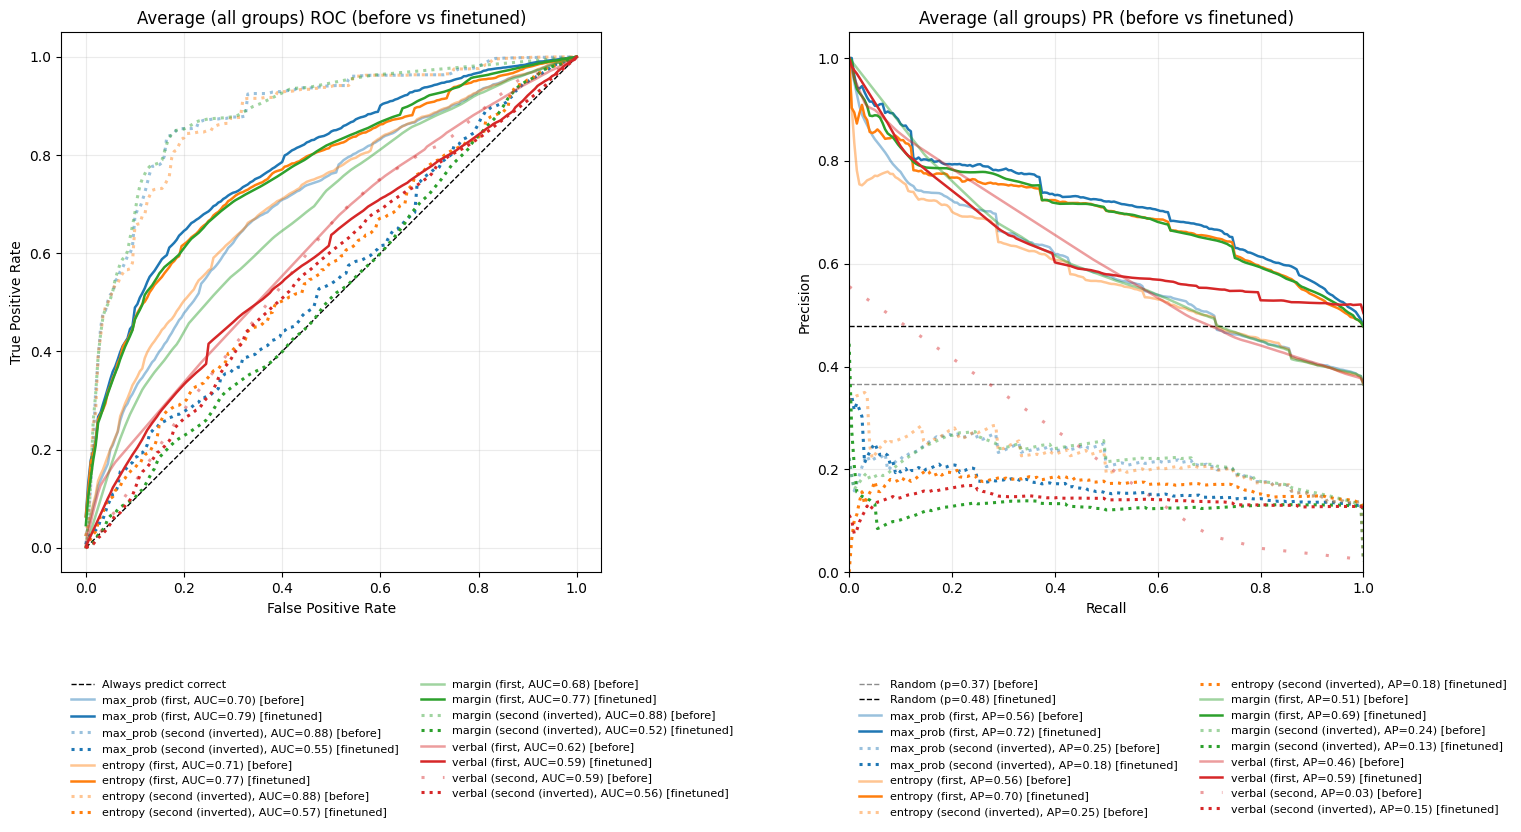

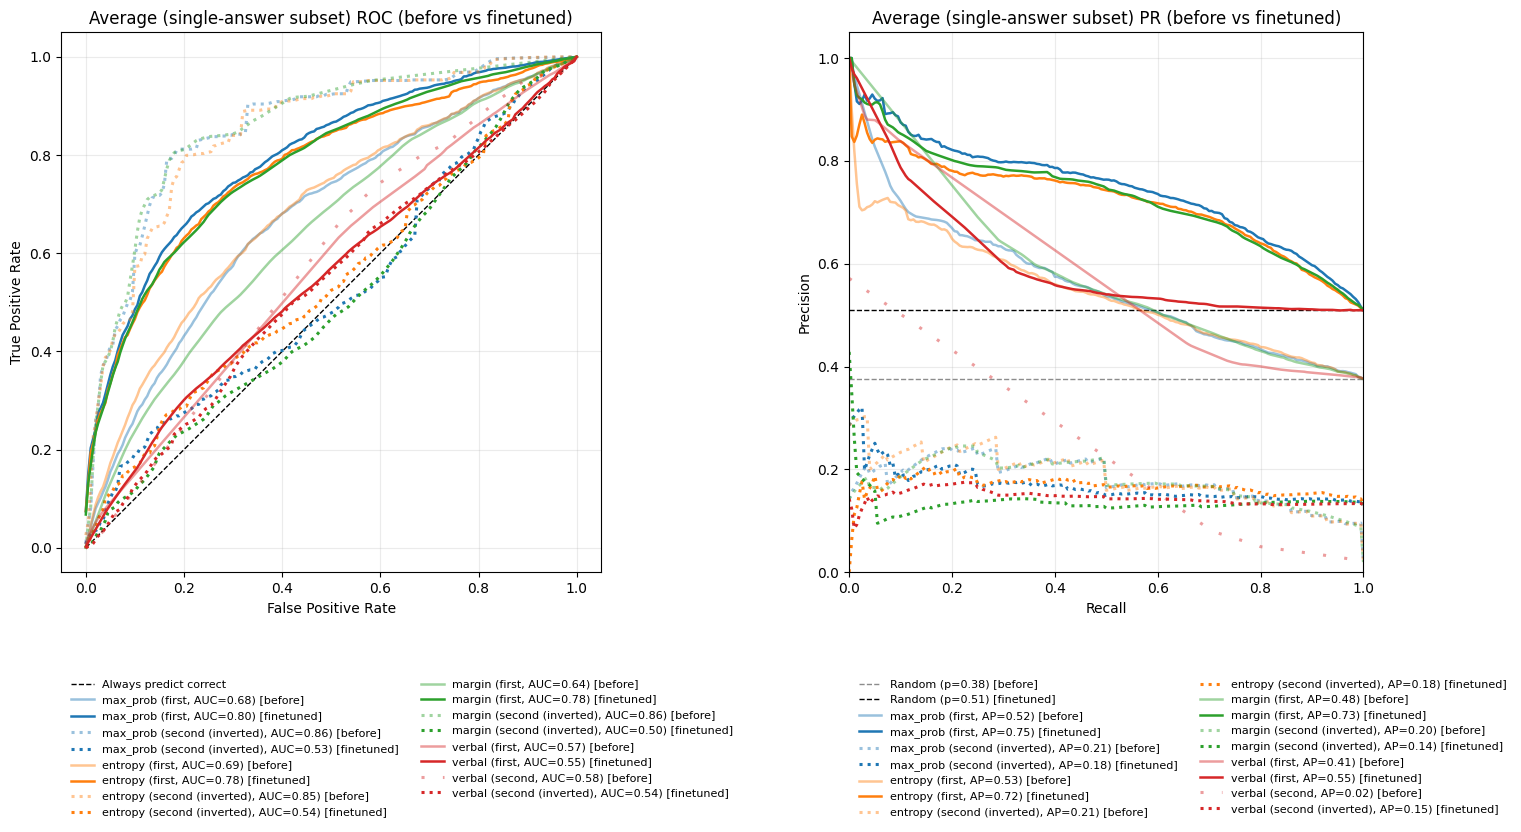

In [37]:
def plot_average_panels_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
    before_alpha: float = 0.45,
    finetuned_alpha: float = 1.0,
    fig_title_suffix: str = "(before vs finetuned)",
) -> None:
    dotted_inv = ":"
    dotted_plain_thick = (0, (1, 6))
    lw_first = 1.8
    lw_second = 2.2

    def _style_square(ax):
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.25)

    def _ls_and_lw(try_name: str, inverted: bool) -> tuple[object, float]:
        if try_name == "first":
            return (dotted_inv if inverted else "-"), lw_first
        return (dotted_inv if inverted else dotted_plain_thick), lw_second

    def _plot_roc(ax, frame_before, frame_ft, title):
        curves_before = average_roc_curves(frame_before)
        curves_ft = average_roc_curves(frame_ft)
        ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="Always predict correct")

        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for try_name in ["first", "second"]:
                key = (try_name, metric)
                if key in curves_before:
                    x, y, a_, inv = curves_before[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=before_alpha,
                        label=f"{metric} ({try_name}{inv_tag}, AUC={a_:.2f}) [{before_label}]",
                    )
                if key in curves_ft:
                    x, y, a_, inv = curves_ft[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=finetuned_alpha,
                        label=f"{metric} ({try_name}{inv_tag}, AUC={a_:.2f}) [{finetuned_label}]",
                    )

        ax.set_title(title)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        _style_square(ax)

    def _plot_pr(ax, frame_before, frame_ft, title):
        roc_before = average_roc_curves(frame_before)
        roc_ft = average_roc_curves(frame_ft)
        orient_before = {k: inv for k, (_x, _y, _auc, inv) in roc_before.items()}
        orient_ft = {k: inv for k, (_x, _y, _auc, inv) in roc_ft.items()}
        curves_before = average_pr_curves(frame_before, orientation=orient_before)
        curves_ft = average_pr_curves(frame_ft, orientation=orient_ft)

        base_before = average_pr_baseline(frame_before)
        base_ft = average_pr_baseline(frame_ft)
        ax.plot(
            [0, 1],
            [base_before, base_before],
            "k--",
            lw=1.0,
            alpha=before_alpha,
            label=f"Random (p={base_before:.2f}) [{before_label}]",
        )
        ax.plot(
            [0, 1],
            [base_ft, base_ft],
            "k--",
            lw=1.0,
            alpha=finetuned_alpha,
            label=f"Random (p={base_ft:.2f}) [{finetuned_label}]",
        )

        for metric in METRICS:
            color = METRIC_COLORS[metric]
            for try_name in ["first", "second"]:
                key = (try_name, metric)
                if key in curves_before:
                    x, y, ap, inv = curves_before[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=before_alpha,
                        label=f"{metric} ({try_name}{inv_tag}, AP={ap:.2f}) [{before_label}]",
                    )
                if key in curves_ft:
                    x, y, ap, inv = curves_ft[key]
                    ls, lw = _ls_and_lw(try_name, inv)
                    inv_tag = " (inverted)" if inv else ""
                    ax.plot(
                        x,
                        y,
                        linestyle=ls,
                        color=color,
                        lw=lw,
                        alpha=finetuned_alpha,
                        label=f"{metric} ({try_name}{inv_tag}, AP={ap:.2f}) [{finetuned_label}]",
                    )

        ax.set_title(title)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        _style_square(ax)

    def _plot_pair(frame_before, frame_ft, *, title_prefix: str):
        fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(18, 9))
        _plot_roc(ax_roc, frame_before, frame_ft, f"{title_prefix} ROC {fig_title_suffix}")
        _plot_pr(ax_pr, frame_before, frame_ft, f"{title_prefix} PR {fig_title_suffix}")

        ax_roc.legend(
            loc="upper left",
            bbox_to_anchor=(0.0, -0.18),
            ncol=2,
            fontsize=8,
            frameon=False,
        )
        ax_pr.legend(
            loc="upper left",
            bbox_to_anchor=(0.0, -0.18),
            ncol=2,
            fontsize=8,
            frameon=False,
        )

        fig.subplots_adjust(bottom=0.28, wspace=0.25)
        plt.show()

    _plot_pair(before_all, finetuned_all, title_prefix="Average (all groups)")
    _plot_pair(before_single, finetuned_single, title_prefix="Average (single-answer subset)")


plot_average_panels_compare(
    before_df,
    before_single,
    finetuned_df,
    finetuned_single,
)

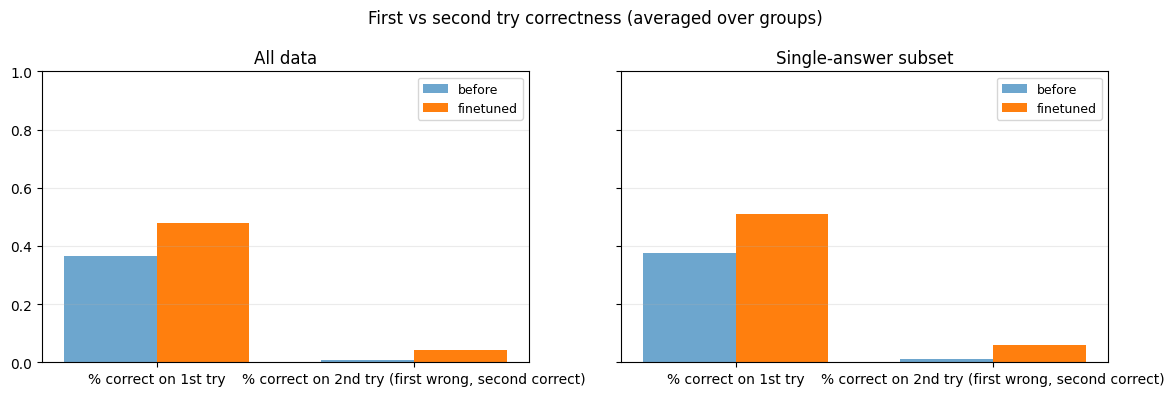

,dataset,categorie,subcategorie,n_before,first_rate_before,second_rate_before,n_finetuned,first_rate_finetuned,second_rate_finetuned,first_rate_delta,second_rate_delta
0,gsm8k_test,math,NA,1319,0.166035,0.007582,1238,0.274637,0.109047,0.108602,0.101465
1,gsm8k_train,math,NA,7473,0.174093,0.015523,7073,0.331684,0.097554,0.157590,0.082032
2,maqa_commonsense_reasoning,commonsense single,NA,8434,0.632203,0.014228,8430,0.815184,0.029537,0.182981,0.015309
3,maqa_mathematical_reasoning,math,multi,400,0.387500,0.007500,399,0.458647,0.020050,0.071147,0.012550
4,maqa_single_commonsense_reasoning,commonsense single,NA,2290,0.638865,0.012227,2290,0.806987,0.031004,0.168122,0.018777
5,maqa_single_math_reasoning,math,single,1319,0.165277,0.010614,1241,0.282836,0.119259,0.117560,0.108645
6,maqa_single_world_knowledge_nq,world knowledge,single NQ,1288,0.214286,0.002329,1288,0.278727,0.014752,0.064441,0.012422
7,maqa_world_knowledge_hls,world knowledge,multi HLS,50,0.140000,0.000000,50,0.160000,0.000000,0.020000,0.000000
8,maqa_world_knowledge_nq,world knowledge,multi NQ,592,0.228041,0.000000,592,0.256757,0.000000,0.028716,0.000000
9,strategyqa_dev,NA,NA,229,0.628821,0.008734,229,0.794760,0.017467,0.165939,0.008734


In [38]:
def rates_by_group(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, categorie, subcategorie), g in iter_groups(frame):
        first_rate = float(g["first_try_correct"].mean()) if len(g) else 0.0
        second_rate = float(_second_try_gain(g).mean()) if len(g) else 0.0
        rows.append({
            "dataset": dataset,
            "categorie": categorie,
            "subcategorie": subcategorie,
            "n": int(len(g)),
            "first_rate": first_rate,
            "second_rate": second_rate,
        })
    out = pd.DataFrame(rows)
    return out.sort_values(["dataset", "categorie", "subcategorie"]).reset_index(drop=True)


def plot_first_vs_second_rates_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (title, b_frame, f_frame) in zip(
        axes,
        [
            ("All data", before_all, finetuned_all),
            ("Single-answer subset", before_single, finetuned_single),
        ],
    ):
        b = rates_by_group(b_frame)[["first_rate", "second_rate"]].mean()
        f = rates_by_group(f_frame)[["first_rate", "second_rate"]].mean()

        x = np.arange(2)
        w = 0.36
        ax.bar(x - w / 2, [b["first_rate"], b["second_rate"]], width=w, label=before_label, alpha=0.65)
        ax.bar(x + w / 2, [f["first_rate"], f["second_rate"]], width=w, label=finetuned_label, alpha=1.0)
        ax.set_xticks(x)
        ax.set_xticklabels([
            "% correct on 1st try",
            "% correct on 2nd try (first wrong, second correct)",
        ])
        ax.set_title(title)
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", alpha=0.25)
        ax.legend(fontsize=9)
    fig.suptitle("First vs second try correctness (averaged over groups)")
    plt.tight_layout()
    plt.show()


plot_first_vs_second_rates_compare(before_df, before_single, finetuned_df, finetuned_single)


# Per-group comparison table (before vs finetuned)
before_group_all = rates_by_group(before_df).rename(
    columns={
        "first_rate": "first_rate_before",
        "second_rate": "second_rate_before",
        "n": "n_before",
    }
)
finetuned_group_all = rates_by_group(finetuned_df).rename(
    columns={
        "first_rate": "first_rate_finetuned",
        "second_rate": "second_rate_finetuned",
        "n": "n_finetuned",
    }
)

group_cmp_all = before_group_all.merge(
    finetuned_group_all,
    on=["dataset", "categorie", "subcategorie"],
    how="outer",
)
group_cmp_all["first_rate_delta"] = group_cmp_all["first_rate_finetuned"] - group_cmp_all["first_rate_before"]
group_cmp_all["second_rate_delta"] = group_cmp_all["second_rate_finetuned"] - group_cmp_all["second_rate_before"]

group_cmp_all.sort_values(["dataset", "categorie", "subcategorie"]).head(20)

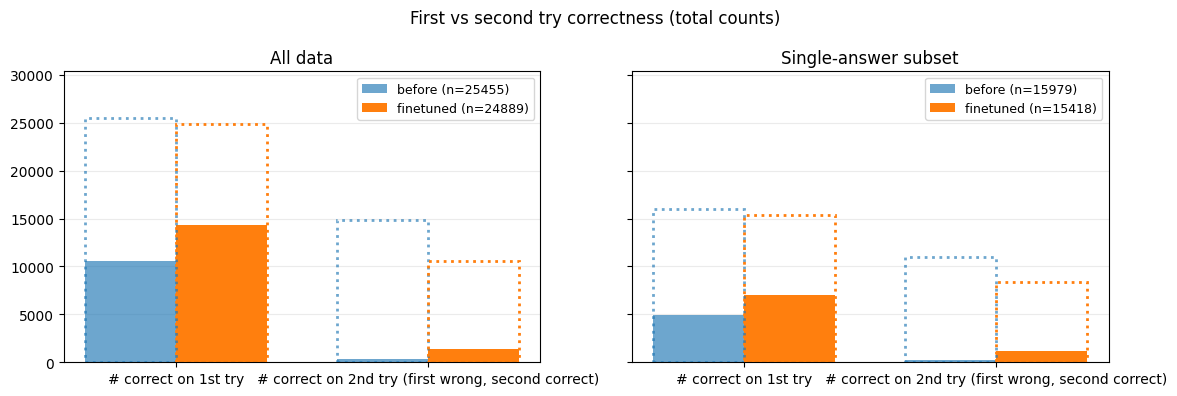

In [44]:
def total_counts(frame: pd.DataFrame) -> dict[str, int]:
    n = int(len(frame))
    first_correct = int(frame["first_try_correct"].sum()) if n else 0
    second_gain = int(_second_try_gain(frame).sum()) if n else 0
    # Count questions that got a second try (where first try was wrong)
    n_second_try = int((frame["first_try_correct"] == 0).sum()) if n else 0
    return {"n": n, "first_correct": first_correct, "second_gain": second_gain, "n_second_try": n_second_try}


def plot_first_vs_second_counts_compare(
    before_all: pd.DataFrame,
    before_single: pd.DataFrame,
    finetuned_all: pd.DataFrame,
    finetuned_single: pd.DataFrame,
    *,
    before_label: str = "before",
    finetuned_label: str = "finetuned",
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, (title, b_frame, f_frame) in zip(
        axes,
        [
            ("All data", before_all, finetuned_all),
            ("Single-answer subset", before_single, finetuned_single),
        ],
    ):
        b = total_counts(b_frame)
        f = total_counts(f_frame)

        x = np.arange(2)
        w = 0.36
        before_bars = ax.bar(
            x - w / 2,
            [b["first_correct"], b["second_gain"]],
            width=w,
            label=f"{before_label} (n={b['n']})",
            alpha=0.65,
            zorder=2,
        )
        finetuned_bars = ax.bar(
            x + w / 2,
            [f["first_correct"], f["second_gain"]],
            width=w,
            label=f"{finetuned_label} (n={f['n']})",
            alpha=1.0,
            zorder=2,
        )

        before_color = before_bars.patches[0].get_facecolor() if before_bars.patches else "C0"
        finetuned_color = finetuned_bars.patches[0].get_facecolor() if finetuned_bars.patches else "C1"

        # Total questions overlays: empty bars with dotted outlines, same color as each series
        # For first try: show total n
        # For second try: show only questions that got a second try (where first was wrong)
        ax.bar(
            x - w / 2,
            [b["n"], b["n_second_try"]],
            width=w,
            facecolor="none",
            edgecolor=before_color,
            linewidth=2.0,
            linestyle=":",
            zorder=3,
        )
        ax.bar(
            x + w / 2,
            [f["n"], f["n_second_try"]],
            width=w,
            facecolor="none",
            edgecolor=finetuned_color,
            linewidth=2.0,
            linestyle=":",
            zorder=3,
        )

        ax.set_xticks(x)
        ax.set_xticklabels([
            "# correct on 1st try",
            "# correct on 2nd try (first wrong, second correct)",
        ])
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.25, zorder=0)
        ax.legend(fontsize=9)

        ymax = max(b["n"], f["n"], 1)
        ax.set_ylim(0, ymax * 1.9)

    fig.suptitle("First vs second try correctness (total counts)")
    plt.tight_layout()
    plt.show()


plot_first_vs_second_counts_compare(before_df, before_single, finetuned_df, finetuned_single)